# Hands-on Week 14

> Nama: Sahda Huwaidah Estiningtyas

> NIM: 24/545080/PA/23156

> email: sahdahuwaidahestiningtyas@mail.ugm.ac.id

## Bagian A -  Mini Case Study: Prediksi Progression Diabetes

Tujuan utama analisis ini adalah memahami bagaimana beberapa variabel prediktor digunakan secara bersama-sama untuk memprediksi variabel target. Data yang digunakan adalah dat **diabetes** dari `sklearn.datasets`

Variabel prediktor yang digunakan adalah:

- `age` → usia pasien
- `bmi` → body mass index
- `bp` → tekanan darah rata-rata

Sedangkan variabel target adalah:

- `target` → perkembangan penyakit diabetes setelah satu tahun

> Fokus kegiatan ini adalah memahami alur regresi linear berganda, interpretasi koefisien, evaluasi model, dan visualisasi hasil prediksi.


## 1. Import library

**Arahan**
1. Import library yang diperlukan.
2. Gunakan:
   - `numpy`
   - `pandas`
   - `matplotlib.pyplot`
   - `load_diabetes` dari `sklearn.datasets`
3. Import:
   - `load_diabetes`
   - `train_test_split`
   - `LinearRegression`
   - metrik evaluasi dari `sklearn.metrics`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, r2_score)

RANDOM_STATE = 42
pd.set_option("display.precision", 4)

## 2. Memuat dataset diabetes

**Arahan**
1. Load dataset diabetes menggunakan `load_diabetes()`.
2. Simpan fitur ke dalam DataFrame.
3. Tambahkan variabel target ke dalam DataFrame.
4. Tampilkan lima baris pertama dataset.


In [5]:
# Load dataset Diabetes
diabetes = load_diabetes()
X_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_diabetes = pd.Series(diabetes.target, name="target")
diabetes_df = X_diabetes.copy()
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466


**Interpretasi mahasiswa:**

Dataset diabetes terdiri atas beberapa variabel prediktor numerik dan satu variabel target. Setiap baris merepresentasikan satu observasi pasien, sedangkan kolom target menunjukkan perkembangan penyakit diabetes setelah satu tahun.

## 3. Memilih variabel prediktor dan target

**Arahan**
1. Gunakan variabel:
   - `age`
   - `bmi`
   - `bp`
   
   sebagai variabel prediktor.
2. Gunakan `target` sebagai variabel target.
3. Simpan prediktor ke variabel `X`.
4. Simpan target ke variabel `y`.


In [7]:
# Memilih variabel prediktor dan target
X = diabetes_df[["age", "bmi", "bp"]]
y = y_diabetes
print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)
X.head()

Ukuran X: (442, 3)
Ukuran y: (442,)


,age,bmi,bp
0,0.0381,0.0617,0.0219
1,-0.0019,-0.0515,-0.0263
2,0.0853,0.0445,-0.0057
3,-0.0891,-0.0116,-0.0367
4,0.0054,-0.0364,0.0219


## 4. Eksplorasi data

**Arahan**
1. Tampilkan ukuran dataset.
2. Periksa missing value.
3. Tampilkan statistik deskriptif.


In [8]:
# A.4 Eksplorasi data
print("Ukuran dataset:", diabetes_df.shape)
print("\nMissing value:")
print(diabetes_df.isnull().sum())
print("\nStatistik deskriptif:")
diabetes_df.describe()

Ukuran dataset: (442, 10)

Missing value:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Statistik deskriptif:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02
mean,-2.5118e-19,1.2308e-17,-2.2456e-16,-4.7976e-17,-1.3815e-17,3.9184e-17,-5.7772e-18,-9.0425e-18,9.2937e-17,1.1303e-17
std,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02
min,-1.0723e-01,-4.4642e-02,-9.0275e-02,-1.1240e-01,-1.2678e-01,-1.1561e-01,-1.0231e-01,-7.6395e-02,-1.2610e-01,-1.3777e-01
25%,-3.7299e-02,-4.4642e-02,-3.4229e-02,-3.6656e-02,-3.4248e-02,-3.0358e-02,-3.5117e-02,-3.9493e-02,-3.3246e-02,-3.3179e-02
50%,5.3831e-03,-4.4642e-02,-7.2838e-03,-5.6704e-03,-4.3209e-03,-3.8191e-03,-6.5845e-03,-2.5923e-03,-1.9472e-03,-1.0777e-03
75%,3.8076e-02,5.0680e-02,3.1248e-02,3.5644e-02,2.8358e-02,2.9844e-02,2.9312e-02,3.4309e-02,3.2432e-02,2.7917e-02
max,1.1073e-01,5.0680e-02,1.7056e-01,1.3204e-01,1.5391e-01,1.9879e-01,1.8118e-01,1.8523e-01,1.3360e-01,1.3561e-01


**Interpretasi mahasiswa:**

Dataset terdiri dari 442 observasi dengan 10 kolom. Tidak terdapat missing value pada seluruh variabel. Statistik deskriptif menunjukkan bahwa seluruh variabel berbentuk numerik dan memiliki rentang nilai yang berbeda-beda.

## 5. Visualisasi hubungan antara prediktor dan target

**Arahan**
1. Buat scatter plot antara masing-masing prediktor dan `target`.
2. Berikan judul grafik.
3. Berikan label pada sumbu-x dan sumbu-y.

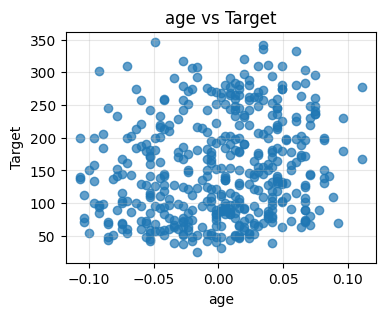

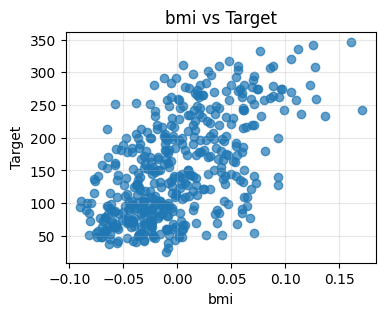

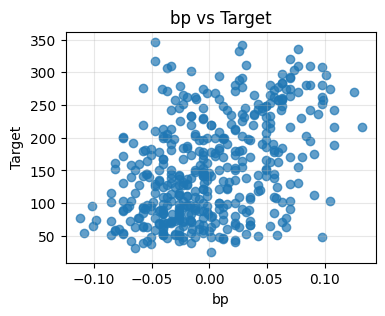

In [13]:
# Visualisasi prediktor dan target
predictors = ["age", "bmi", "bp"]

for var in predictors:
    plt.figure(figsize=(4, 3))

    plt.scatter(
        diabetes_df[var],
        diabetes_df["target"],
        alpha=0.7
    )

    plt.xlabel(var)
    plt.ylabel("Target")
    plt.title(f"{var} vs Target")
    plt.grid(True, alpha=0.3)
    plt.show()

**Interpretasi mahasiswa:**

Berdasarkan scatter plot yang ditampilkan, variabel age menunjukkan hubungan yang relatif lemah terhadap target karena titik data tersebar secara acak tanpa pola yang jelas. Sementara itu, variabel bmi memiliki hubungan positif yang cukup kuat dengan target, terlihat dari kecenderungan nilai target yang meningkat seiring bertambahnya nilai BMI. Variabel bp juga menunjukkan hubungan positif dengan target, meskipun pola yang terbentuk tidak sekuat pada BMI karena sebaran datanya lebih luas. Secara keseluruhan, BMI merupakan variabel yang memiliki hubungan paling kuat dengan target, diikuti oleh BP, sedangkan age memiliki pengaruh yang paling lemah terhadap target.


## 6. Korelasi antar variabel numerik prediktor

**Arahan**
1. Pilih variabel prediktor numerik:
   - `age`
   - `bmi`
   - `bp`
2. Hitung matriks korelasi antar variabel prediktor.
3. Tampilkan hasil matriks korelasi.
4. Buat visualisasi heatmap korelasi.
5. Berikan judul visualisasi yang sesuai.


Matriks korelasi:
        age     bmi      bp
age  1.0000  0.1851  0.3354
bmi  0.1851  1.0000  0.3954
bp   0.3354  0.3954  1.0000


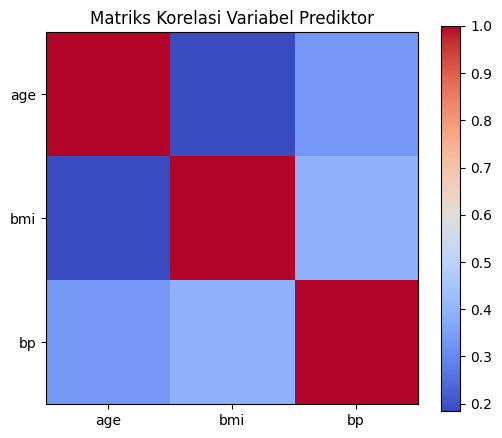

In [14]:
# Korelasi antar variabel prediktor
predictor_df = diabetes_df[["age", "bmi", "bp"]]
corr_matrix = predictor_df.corr()
print("Matriks korelasi:")
print(corr_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)),corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)),corr_matrix.columns)

plt.title("Matriks Korelasi Variabel Prediktor")
plt.show()

**Interpretasi mahasiswa:**

Berdasarkan matriks korelasi antar variabel prediktor, terlihat bahwa hubungan antar fitur age, bmi, dan bp cenderung lemah hingga sedang. Korelasi tertinggi terdapat antara bmi dan bp (0.3954), yang menunjukkan adanya hubungan positif sedang, artinya individu dengan BMI lebih tinggi cenderung memiliki tekanan darah yang juga lebih tinggi, meskipun tidak terlalu kuat. Hubungan antara age dan bp (0.3354) juga menunjukkan korelasi positif sedang, sedangkan age dan bmi (0.1851) memiliki korelasi yang relatif lemah, menandakan bahwa usia tidak terlalu berkaitan erat dengan kondisi BMI.

Secara keseluruhan, tidak terdapat korelasi yang sangat tinggi antar variabel prediktor (tidak mendekati 1 atau -1), sehingga dapat disimpulkan bahwa multikolinearitas antar fitur relatif rendah. Hal ini berarti ketiga variabel tersebut masih cukup independen untuk digunakan bersama dalam model prediksi tanpa adanya redundansi informasi yang berlebihan.


## 7. Membagi data menjadi data latih dan data uji

**Arahan**
1. Bagi data menjadi data latih dan data uji.
2. Gunakan proporsi data uji sebesar 20%.
3. Gunakan `random_state=42`.


In [15]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (353, 3)
Ukuran X_test : (89, 3)
Ukuran y_train: (353,)
Ukuran y_test : (89,)


**Interpretasi mahasiswa:**

Pembagian data menghasilkan 353 data untuk training dan 89 data untuk testing, sesuai dengan proporsi 80% data latih dan 20% data uji. Hal ini menunjukkan bahwa sebagian besar data digunakan untuk melatih model agar dapat mempelajari pola hubungan antara variabel input dan target, sedangkan sebagian kecil data digunakan untuk menguji kemampuan generalisasi model terhadap data baru yang belum pernah dilihat sebelumnya.

## 8. Membuat model regresi linear berganda

**Arahan**
1. Buat model `LinearRegression`.
2. Latih model menggunakan data latih.
3. Tampilkan:
   - intercept
   - koefisien regresi
4. Sajikan koefisien regresi dalam bentuk DataFrame.


In [16]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept:", model.intercept_)

coef_df = pd.DataFrame({"variabel": X.columns, "koefisien": model.coef_})
coef_df

Intercept: 151.76714553333133


,variabel,koefisien
0,age,48.3972
1,bmi,836.1129
2,bp,380.2077


**Interpretasi mahasiswa:**

Intercept sebesar nilai 151.77 yang dihasilkan model menunjukkan perkiraan nilai target ketika seluruh variabel prediktor bernilai 0. Sementara itu, koefisien regresi untuk masing-masing variabel (age, bmi, bp) menunjukkan pengaruh terhadap target, di mana setiap kenaikan 1 unit pada variabel akan mengubah nilai target sebesar nilai koefisiennya dengan asumsi variabel lain tetap. Koefisien positif mencerminkan hubungan searah dengan target, sedangkan koefisien negatif mencerminkan hubungan berlawanan arah. Dari hasil ini dapat dilihat bahwa kontribusi tiap variabel terhadap perubahan target berbeda-beda tergantung besar kecilnya nilai koefisien.


## 9. Membuat prediksi pada data uji

**Arahan**
1. Gunakan model yang telah dilatih.
2. Prediksi nilai target pada data uji.
3. Simpan hasil prediksi pada variabel `y_pred`.
4. Tampilkan beberapa nilai aktual dan prediksi dalam satu DataFrame.


In [17]:
y_pred = model.predict(X_test)
hasil_prediksi = pd.DataFrame({"y_actual": y_test.values, "y_pred": y_pred})
hasil_prediksi.head(10)

,y_actual,y_pred
0,219.0,142.6897
1,70.0,195.4211
2,202.0,146.6801
3,230.0,230.0343
4,111.0,134.6282
5,84.0,121.6847
6,242.0,299.6259
7,272.0,197.0047
8,94.0,50.0097
9,96.0,154.3058


## 10. Evaluasi model regresi

**Arahan**
1. Hitung:
   - Mean Squared Error (MSE)
   - Root Mean Squared Error (RMSE)
   - R-squared
2. Tampilkan hasil evaluasi model.


In [18]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R2  :", round(r2, 4))

MSE : 3756.8366
RMSE: 61.293
R2  : 0.2909


**Interpretasi mahasiswa:**

Nilai MSE sebesar 3756.8366 menunjukkan rata-rata kuadrat error antara nilai aktual dan prediksi model, yang berarti masih terdapat selisih cukup besar antara prediksi dan data sebenarnya. Nilai RMSE sebesar 61.293 menunjukkan bahwa rata-rata kesalahan prediksi model berada pada kisaran sekitar 61 satuan dari nilai target, sehingga secara praktis prediksi model masih memiliki deviasi yang cukup terasa. Sementara itu, nilai R-squared sebesar 0.2909 menunjukkan bahwa model hanya mampu menjelaskan sekitar 29.09% variasi data target, sedangkan sisanya sekitar 70% dipengaruhi oleh faktor lain di luar variabel yang digunakan, sehingga kemampuan model dalam menjelaskan data masih tergolong rendah.

## 11. Visualisasi Actual vs Predicted

**Arahan**
1. Buat scatter plot:
   - sumbu-x → nilai aktual
   - sumbu-y → nilai prediksi
2. Tambahkan garis diagonal referensi.
3. Berikan judul dan label sumbu.


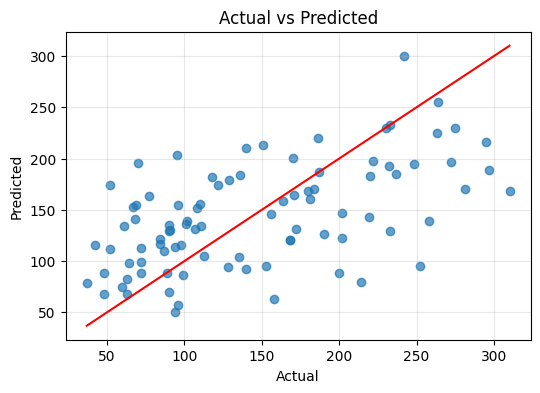

In [19]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.show()

**Interpretasi mahasiswa:**

Pada scatter plot actual vs predicted, titik-titik yang tersebar tidak sepenuhnya mengikuti garis diagonal merah menunjukkan bahwa prediksi model belum akurat secara konsisten. Semakin dekat titik ke garis diagonal berarti nilai prediksi semakin mendekati nilai aktual, sedangkan pada hasil ini terlihat banyak titik yang menyebar cukup jauh dari garis. Hal ini mencerminkan adanya error prediksi yang cukup besar, sesuai dengan nilai RMSE yang juga cukup tinggi, sehingga model masih belum mampu memprediksi target dengan presisi yang baik.

## 12. Visualisasi residual

Residual merupakan selisih antara nilai aktual dan nilai prediksi.

$ Residual = y_{actual} - y_{predicted}$

**Arahan**
1. Hitung residual model.
2. Buat scatter plot:
   - sumbu-x → nilai prediksi
   - sumbu-y → residual
3. Tambahkan garis horizontal pada residual = 0.
4. Berikan judul dan label sumbu.


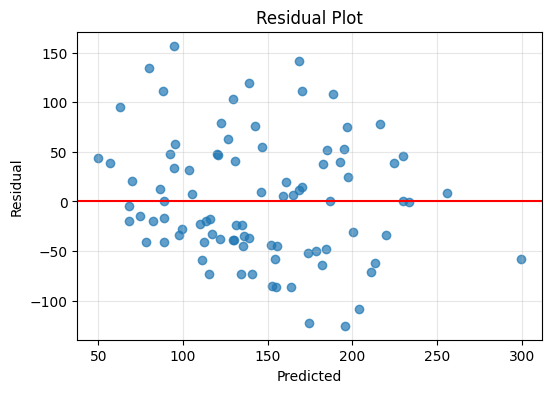

In [21]:
residual = y_test - y_pred
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residual, alpha=0.7)
plt.axhline(y=0, color="red")

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)
plt.show()

**Interpretasi mahasiswa:**

Residual dihitung sebagai selisih antara nilai aktual dan nilai prediksi, dan pada plot ini residual seharusnya tersebar acak di sekitar nilai 0 jika model sudah baik. Namun dari hasil visualisasi, residual memang menyebar di sekitar garis nol tetapi masih terlihat adanya pola penyebaran tertentu dan tidak sepenuhnya acak sempurna. Hal ini menunjukkan bahwa masih terdapat struktur hubungan dalam data yang belum tertangkap oleh model, yang sejalan dengan nilai R-squared yang rendah, sehingga model masih memiliki keterbatasan dalam menjelaskan variasi data target.


# 13. Interpretasi akhir

Dari seluruh proses analisis regresi linear berganda pada dataset diabetes dengan variabel age, bmi, dan bp, dapat disimpulkan bahwa model yang dibangun masih memiliki kemampuan prediksi yang terbatas. Hal ini terlihat dari nilai R-squared sebesar 0.2909 yang menunjukkan bahwa hanya sekitar 29% variasi pada target yang dapat dijelaskan oleh ketiga variabel prediktor, sementara sisanya dipengaruhi oleh faktor lain yang tidak dimasukkan dalam model.

Nilai RMSE yang cukup besar (61.293) juga menunjukkan bahwa rata-rata kesalahan prediksi masih cukup signifikan, sehingga prediksi model belum cukup dekat dengan nilai aktual. Hal ini diperkuat oleh visualisasi actual vs predicted yang menunjukkan sebaran titik yang cukup jauh dari garis diagonal, serta residual plot yang belum sepenuhnya acak.

Secara keseluruhan, model linear yang digunakan belum mampu menangkap kompleksitas hubungan antara variabel prediktor dan target dengan baik. Ini menunjukkan bahwa hubungan dalam data kemungkinan tidak sepenuhnya linear, atau terdapat variabel lain yang lebih berpengaruh tetapi tidak digunakan dalam model.


## Bagian B -  Mini Case Study: Classification and Clustering dengan Wine Dataset

Pada bagian ini kita menggunakan **Wine Dataset** dari `sklearn.datasets` untuk mempelajari dua pendekatan utama dalam machine learning:

Wine Dataset berisi hasil pengukuran kimia dari beberapa jenis wine.  
Dataset ini memiliki 13 fitur numerik dan 3 kelas wine.

> Fokus kegiatan ini adalah memahami alur dasar classification, clustering, evaluasi model, dan interpretasi hasil.


## 1. Import library

**Arahan**
1. Import library yang diperlukan.
2. Gunakan `numpy`, `pandas`, dan `matplotlib.pyplot`.
3. Gunakan `load_wine` dari `sklearn.datasets`.
4. Gunakan fungsi dari `sklearn` untuk:
   - membagi data,
   - standardisasi,
   - classification,
   - clustering,
   - evaluasi model,
   - PCA.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score
)
RANDOM_STATE = 42

## 2. Memuat Wine Dataset

**Arahan**
1. Load Wine Dataset menggunakan `load_wine()`.
2. Simpan fitur ke dalam DataFrame.
3. Tambahkan kolom target.
4. Tambahkan kolom nama kelas wine.
5. Tampilkan lima baris pertama data.


In [23]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="wine_class")
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


**Interpretasi mahasiswa:**

Wine Dataset memiliki struktur data tabular dengan 178 observasi dan 13 fitur numerik sebagai variabel prediktor. Setiap observasi merepresentasikan sampel wine yang memiliki karakteristik kimia tertentu, sedangkan variabel target menunjukkan kelas wine yang terdiri dari 3 kategori. Dengan demikian, dataset ini termasuk supervised learning karena sudah memiliki label kelas yang jelas.

## 3. Eksplorasi awal dataset

**Arahan**
1. Tampilkan ukuran dataset.
2. Tampilkan nama-nama fitur.
3. Tampilkan jumlah observasi untuk setiap kelas wine.
4. Periksa apakah terdapat missing value.
5. Tampilkan ringkasan statistik deskriptif.
6. Buat scatter plot antara variabel target dengan dua variabel prediktor (fitur numerik)


In [24]:
print("Ukuran dataset:", X.shape)
print("\nMissing value:")
print(X.isnull().sum())
print("\nStatistik deskriptif:")
X.describe()

Ukuran dataset: (178, 13)

Missing value:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Statistik deskriptif:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000
mean,13.0006,2.3363,2.3665,19.4949,99.7416,2.2951,2.0293,0.3619,1.5909,5.0581,0.9574,2.6117,746.8933
std,0.8118,1.1171,0.2743,3.3396,14.2825,0.6259,0.9989,0.1245,0.5724,2.3183,0.2286,0.7100,314.9075
min,11.0300,0.7400,1.3600,10.6000,70.0000,0.9800,0.3400,0.1300,0.4100,1.2800,0.4800,1.2700,278.0000
25%,12.3625,1.6025,2.2100,17.2000,88.0000,1.7425,1.2050,0.2700,1.2500,3.2200,0.7825,1.9375,500.5000
50%,13.0500,1.8650,2.3600,19.5000,98.0000,2.3550,2.1350,0.3400,1.5550,4.6900,0.9650,2.7800,673.5000
75%,13.6775,3.0825,2.5575,21.5000,107.0000,2.8000,2.8750,0.4375,1.9500,6.2000,1.1200,3.1700,985.0000
max,14.8300,5.8000,3.2300,30.0000,162.0000,3.8800,5.0800,0.6600,3.5800,13.0000,1.7100,4.0000,1680.0000


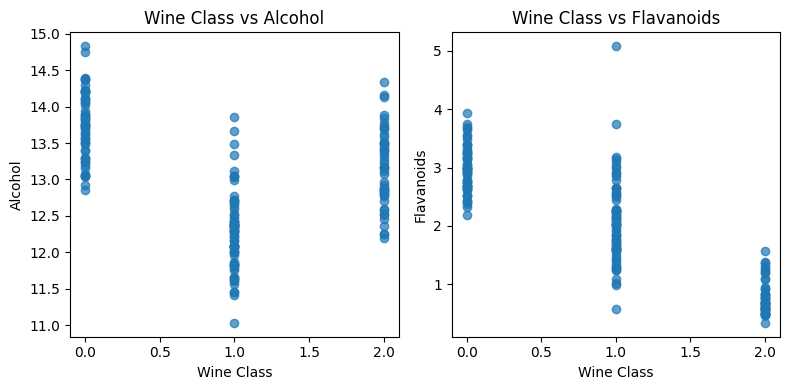

In [26]:
# Tambahkan kolom target ke DataFrame
wine_df = X.copy()
wine_df["wine_class"] = y

# Scatter plot: target vs dua fitur numerik
plt.figure(figsize=(8, 4))

# Plot 1: alcohol vs wine class
plt.subplot(1, 2, 1)
plt.scatter(wine_df["wine_class"], wine_df["alcohol"], alpha=0.7)
plt.xlabel("Wine Class")
plt.ylabel("Alcohol")
plt.title("Wine Class vs Alcohol")

# Plot 2: flavanoids vs wine class
plt.subplot(1, 2, 2)
plt.scatter(wine_df["wine_class"], wine_df["flavanoids"], alpha=0.7)
plt.xlabel("Wine Class")
plt.ylabel("Flavanoids")
plt.title("Wine Class vs Flavanoids")

plt.tight_layout()
plt.show()

**Interpretasi mahasiswa:**

Dataset sudah siap digunakan untuk analisis classification dan clustering karena tidak terdapat missing value, data bersifat numerik, dan distribusi kelas cukup jelas. Hasil visualisasi juga menunjukkan adanya perbedaan pola antara kelas wine berdasarkan fitur seperti alcohol dan flavanoids, yang mengindikasikan bahwa kelas-kelas tersebut memiliki karakteristik yang dapat dipisahkan. Oleh karena itu, dataset ini layak digunakan untuk membangun model klasifikasi maupun clustering.

# B1 — Classification

Pada bagian ini, kita akan membangun model klasifikasi untuk memprediksi kelas wine berdasarkan fitur kimia yang tersedia.


## 4. Menyiapkan data untuk classification

**Arahan**
1. Simpan seluruh fitur numerik ke variabel `X`.
2. Simpan target ke variabel `y`.
3. Bagi data menjadi data latih dan data uji.
4. Gunakan proporsi data uji sebesar 20%.
5. Gunakan `random_state=42`.
6. Gunakan `stratify=y` agar proporsi kelas tetap seimbang.


In [27]:
# Train-test split
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="wine_class")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (142, 13)
Ukuran X_test : (36, 13)
Ukuran y_train: (142,)
Ukuran y_test : (36,)


## 5. Standardisasi fitur

**Arahan**
1. Gunakan `StandardScaler`.
2. Lakukan fitting scaler pada data latih.
3. Transformasikan data latih dan data uji.
4. Simpan hasilnya sebagai `X_train_scaled` dan `X_test_scaled`.


In [31]:
# Standardisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Interpretasi mahasiswa:**

Standardisasi penting ketika fitur memiliki skala yang berbeda-beda karena beberapa algoritma seperti logistic regression sensitif terhadap besar kecilnya nilai fitur. Tanpa standardisasi, fitur dengan nilai besar dapat mendominasi proses pembelajaran model, sehingga mengganggu estimasi parameter. Dengan standardisasi, setiap fitur berada pada skala yang sama sehingga kontribusinya terhadap model menjadi lebih seimbang.


## 6. Membuat model Logistic Regression

**Arahan**
1. Buat model `LogisticRegression`.
2. Gunakan `max_iter=1000`.
3. Latih model menggunakan data latih yang sudah distandardisasi.
4. Buat prediksi pada data uji.


In [32]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 2, 2])

## 7. Evaluasi model classification

**Arahan**
1. Hitung nilai accuracy, precision, recall, f1-score.
2. Tampilkan classification report.


In [33]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.9722
Precision: 0.9741
Recall   : 0.9722
F1-score : 0.972

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



**Interpretasi mahasiswa:**

Nilai accuracy sebesar 0.9722 menunjukkan bahwa model mampu mengklasifikasikan sebagian besar data dengan benar. Precision yang tinggi (0.9741) menunjukkan bahwa prediksi kelas oleh model cukup akurat, sedangkan recall sebesar 0.9722 menunjukkan bahwa model mampu menangkap sebagian besar data pada setiap kelas dengan baik. F1-score sebesar 0.972 menunjukkan keseimbangan yang sangat baik antara precision dan recall, sehingga secara keseluruhan model memiliki performa yang sangat baik dalam klasifikasi Wine Dataset.

## 8. Visualisasi confusion matrix

**Arahan**
1. Buat visualisasi confusion matrix.
2. Gunakan nama kelas wine sebagai label.
3. Berikan judul grafik.


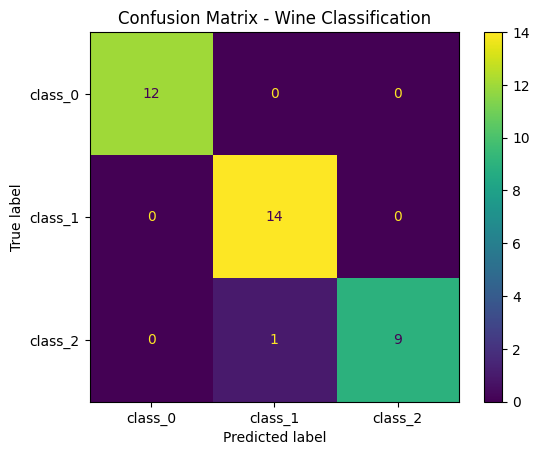

In [34]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Wine Classification")
plt.grid(False)
plt.show()

**Interpretasi mahasiswa:**

Berdasarkan confusion matrix, kelas class_0 dan class_1 dapat diklasifikasikan dengan sangat baik karena seluruh data pada kedua kelas tersebut berada tepat di diagonal utama (tidak ada kesalahan klasifikasi). Kelas class_2 merupakan kelas yang paling sulit diklasifikasikan, karena terdapat 1 data yang salah diprediksi sebagai class_1. Hal ini menunjukkan bahwa sebagian kecil sampel class_2 memiliki karakteristik yang mirip dengan class_1 sehingga model mengalami sedikit kesulitan dalam membedakan kedua kelas tersebut.

# B2 — Clustering

Pada bagian ini, kita akan menggunakan k-means untuk mengelompokkan data Wine tanpa menggunakan label kelas asli.


## 9. Menyiapkan data untuk clustering

**Arahan**
1. Gunakan seluruh fitur numerik pada Wine Dataset.
2. Lakukan standardisasi fitur.
3. Simpan data hasil standardisasi ke variabel `X_scaled`.


In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Ukuran X_scaled:", X_scaled.shape)

Ukuran X_scaled: (178, 13)


## 10. Menjalankan K-Means Clustering

**Arahan**
1. Gunakan `KMeans`.
2. Tentukan jumlah cluster sebanyak 3.
3. Gunakan `random_state=42`.
4. Gunakan `n_init=10`.
5. Simpan label cluster ke dalam DataFrame.


In [36]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
cluster_label = kmeans.fit_predict(X_scaled)
wine_df["cluster"] = cluster_label
print("Label cluster unik:", np.unique(cluster_label))
print("Inertia:", kmeans.inertia_)
wine_df.head()

Label cluster unik: [0 1 2]
Inertia: 1277.928488844643


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class,cluster
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,2
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,2
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,2
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,2


**Interpretasi mahasiswa:**

Hasil K-Means clustering menunjukkan bahwa data Wine berhasil dikelompokkan menjadi 3 cluster sesuai dengan parameter yang ditentukan (n_clusters=3). Label cluster yang dihasilkan adalah 0, 1, dan 2, yang merupakan hasil pengelompokan berdasarkan kemiripan fitur setelah dilakukan standardisasi. Nilai inertia yang dihasilkan menunjukkan tingkat variasi dalam cluster, di mana semakin kecil nilainya maka semakin rapat data dalam masing-masing cluster. Dalam hasil ini, inertia masih cukup besar karena data memiliki banyak fitur (13 fitur) sehingga variasi dalam data masih cukup kompleks.

## 11. Membandingkan cluster dengan kelas asli

**Arahan**
1. Buat tabel silang antara label cluster dan kelas wine asli.
2. Tampilkan hasilnya.
3. Ingat bahwa nomor cluster tidak harus sama dengan nomor kelas asli.


In [37]:
pd.crosstab(wine_df["cluster"], wine_df["wine_class"])

wine_class,0,1,2
cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


**Interpretasi mahasiswa:**

Hasil tabel silang (crosstab) menunjukkan hubungan antara label cluster dan kelas wine asli. Dari tabel tersebut terlihat bahwa masing-masing cluster cukup banyak mengelompokkan data dari kelas tertentu, meskipun tidak sepenuhnya sempurna. Beberapa cluster didominasi oleh satu kelas tertentu, tetapi masih terdapat beberapa data dari kelas lain yang masuk ke cluster yang sama. Hal ini menunjukkan bahwa algoritma K-Means mampu menangkap pola utama dalam data, namun belum sepenuhnya sama dengan label asli karena K-Means bekerja secara unsupervised tanpa mengetahui kelas sebenarnya.

## 12. Evaluasi clustering dengan silhouette score

**Arahan**
1. Hitung nilai silhouette score.
2. Tampilkan hasilnya.
3. Jelaskan secara singkat makna nilai silhouette score.


In [38]:
score = silhouette_score(X_scaled, cluster_label)
print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.2849


**Interpretasi mahasiswa:**

Nilai silhouette score sebesar 0.2849 menunjukkan bahwa kualitas clustering berada pada tingkat rendah hingga sedang. Nilai ini mengindikasikan bahwa jarak antar cluster belum terlalu jelas, sehingga masih terdapat overlap antar cluster. Secara umum, semakin mendekati 1 maka clustering semakin baik, sedangkan nilai mendekati 0 menunjukkan bahwa batas antar cluster kurang jelas. Dalam kasus ini, hasil clustering belum optimal, tetapi masih mampu membentuk struktur kelompok tertentu dalam data Wine


## 13. Profil cluster berdasarkan rata-rata fitur asli

**Arahan**
1. Kelompokkan data berdasarkan label cluster.
2. Hitung rata-rata setiap fitur asli pada masing-masing cluster.
3. Tampilkan profil cluster.


In [39]:
cluster_profile = wine_df.groupby("cluster")[wine.feature_names].mean()
cluster_profile

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,12.2509,1.8974,2.2312,20.0631,92.7385,2.2477,2.0500,0.3577,1.6242,2.9731,1.0627,2.8034,510.1692
1,13.1341,3.3073,2.4176,21.2412,98.6667,1.6839,0.8188,0.4520,1.1459,7.2347,0.6920,1.6967,619.0588
2,13.6768,1.9979,2.4663,17.4629,107.9677,2.8476,3.0032,0.2921,1.9221,5.4535,1.0655,3.1634,1100.2258


**Interpretasi mahasiswa:**

Hasil rata-rata setiap fitur pada masing-masing cluster menunjukkan adanya perbedaan karakteristik antar cluster. Setiap cluster memiliki pola nilai fitur yang berbeda, misalnya pada beberapa fitur seperti alcohol, flavanoids, dan color intensity yang menunjukkan perbedaan rata-rata cukup signifikan antar kelompok. Hal ini menunjukkan bahwa masing-masing cluster memiliki karakteristik kimia wine yang berbeda, sehingga dapat diinterpretasikan bahwa K-Means berhasil membentuk kelompok dengan ciri tertentu meskipun masih terdapat tumpang tindih antar cluster.


# 14. Interpretasi akhir

Secara keseluruhan, hasil clustering menunjukkan bahwa data Wine dapat dikelompokkan menjadi tiga cluster utama berdasarkan kesamaan fitur kimia. Jika dibandingkan dengan kelas asli, hasil clustering sudah cukup mendekati, namun belum sepenuhnya sesuai karena sifat K-Means yang tidak menggunakan label saat proses pembentukan cluster. Evaluasi menggunakan silhouette score juga menunjukkan bahwa kualitas cluster masih sedang, sehingga masih terdapat overlap antar kelompok. Meskipun demikian, clustering tetap berhasil mengungkap struktur utama dalam data dan menunjukkan bahwa terdapat perbedaan karakteristik kimia yang membedakan masing-masing kelompok wine.